In [ ]:
### DATASET Name - height-weight.csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Text(0, 0.5, 'Height')

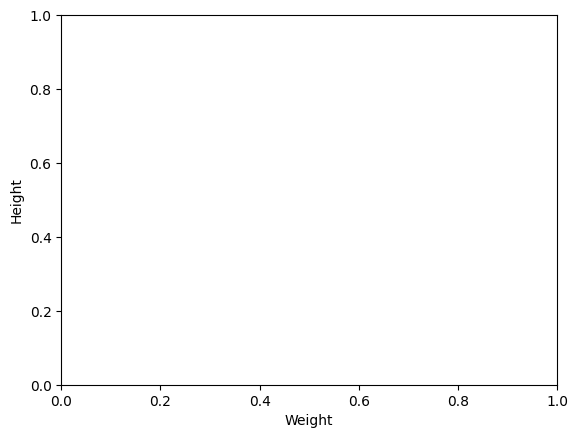

In [ ]:
df = pd.read_csv("height-weight.csv")


In [ ]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

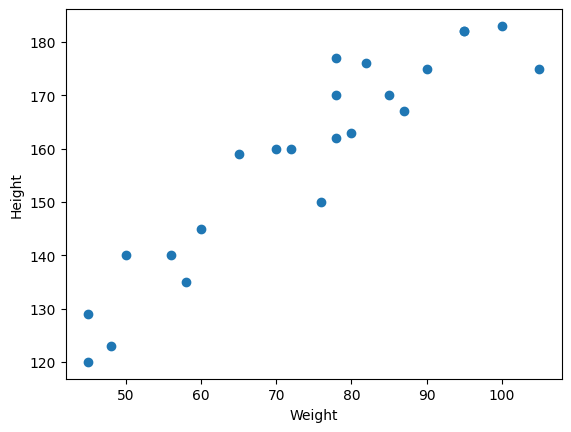

In [ ]:
### scatterplots
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [ ]:
## corelation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


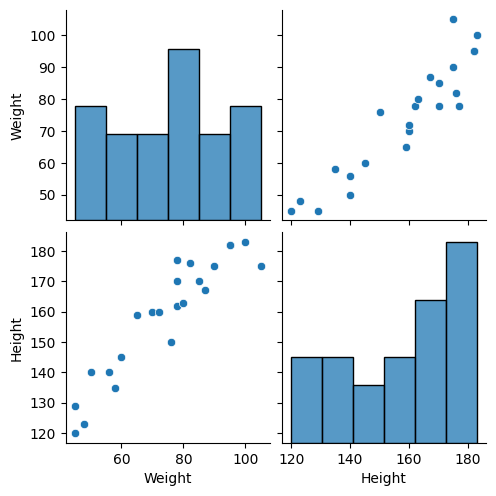

In [ ]:
## Seaborn for visualisation
import seaborn as sns
sns.pairplot(df)

In [ ]:
## independent and dependant features
X = df[['Weight']] ###independent feature should be dataframe or 2 dimentional
y = df['Height'] ## this variable can be in series or 1d array

In [ ]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [ ]:
### TRain Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [ ]:
### Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
## Apply Simple linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [ ]:
print("Coeff or slope :" ,regression.coef_)
print("intercept : " ,regression.intercept_)

Coeff or slope : [16.53415595]
intercept :  159.47058823529412


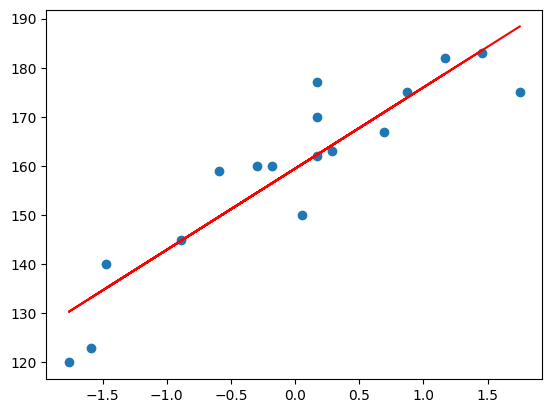

In [ ]:
## Plot training data best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')

In [ ]:
## prediction for test data
y_pred =regression.predict(X_train)

In [ ]:
## Performance matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error
print("MAE : ",mean_absolute_error(y_train,y_pred))
print("MSE : ",mean_squared_error(y_train,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_train,y_pred)))

MAE :  5.911255417295721
MSE :  56.28258679533295
RMSE :  7.502172138476493


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_train,y_pred)
score

0.8292712697975142

In [ ]:
# display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7865890872468928

In [ ]:
## OLS Linear regression
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

In [ ]:
prediction = model.predict(X_test)
print(prediction)

[ 19.24614406   6.66212679 -18.50590775   9.56613077 -29.15392236
 -16.56990509]


In [ ]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.011
Model:                            OLS   Adj. R-squared (uncentered):             -0.051
Method:                 Least Squares   F-statistic:                             0.1716
Date:                Thu, 11 Jun 2026   Prob (F-statistic):                       0.684
Time:                        12:20:21   Log-Likelihood:                         -110.36
No. Observations:                  17   AIC:                                      222.7
Df Residuals:                      16   BIC:                                      223.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
### prediction for new data
regression.predict([[72]])

array([1349.92981637])

In [ ]:
regression.predict(scaler.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([156.45270174])